# 🚗 Car Price Prediction with Machine Learning
**Oasis Infobyte SIP · Data Science Track · Task 3**

**Objective:** Predict the selling price of a used car from features such as brand, age, mileage, fuel type and transmission.

**Pipeline:** Load → Clean → Feature engineering → EDA → Encoding → Correlation → Split → Train 3 models → Evaluate (MAE, RMSE, R²) → Feature importance → Conclusion

**Dataset:** *Vehicle dataset from CardekhO* (Kaggle). Place the CSV next to this notebook and set `DATA_PATH` below.

In [37]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="viridis")
RANDOM_STATE = 42

## 1. Load the data

In [20]:
DATA_PATH = "car data.csv"   # or "CAR DETAILS FROM CAR DEKHO.csv" - both variants are handled below

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [21]:
# Standardise column names so the notebook works with either CardekhO file variant
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={
    "car_name": "name",
    "kms_driven": "km_driven",
    "fuel_type": "fuel",
})
print(df.columns.tolist())
df.info()

['name', 'year', 'selling_price', 'present_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           301 non-null    object 
 1   year           301 non-null    int64  
 2   selling_price  301 non-null    float64
 3   present_price  301 non-null    float64
 4   km_driven      301 non-null    int64  
 5   fuel           301 non-null    object 
 6   seller_type    301 non-null    object 
 7   transmission   301 non-null    object 
 8   owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## 2. Data cleaning

In [22]:
# 2a. Null values
print("Null values per column:")
print(df.isnull().sum())

# Numeric columns -> median, categorical columns -> mode
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype.kind in "biufc":
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

Null values per column:
name             0
year             0
selling_price    0
present_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [23]:
# 2b. Duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows ({before} -> {len(df)})")

Removed 2 duplicate rows (301 -> 299)


In [24]:
# 2c. Inconsistent categorical values (e.g. 'Petrol' vs 'petrol ')
cat_cols = [c for c in ["fuel", "seller_type", "transmission", "owner"] if c in df.columns]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    print(col, "->", df[col].unique().tolist())

fuel -> ['Petrol', 'Diesel', 'Cng']
seller_type -> ['Dealer', 'Individual']
transmission -> ['Manual', 'Automatic']
owner -> ['0', '1', '3']


## 3. Feature engineering

In [25]:
CURRENT_YEAR = datetime.now().year

# Car age from the year column
df["car_age"] = CURRENT_YEAR - df["year"]

# --- Brand extraction ---------------------------------------------------------
# In 'car data.csv', bikes start with a brand ('Bajaj Pulsar 150') but cars only have a
# model name ('ritz', 'city'). So: use the first word when it is a known brand,
# otherwise look the model up in a model -> brand map.
KNOWN_BRANDS = {"bajaj", "hero", "honda", "royal", "yamaha", "ktm", "tvs", "hyosung",
                "mahindra", "suzuki", "um", "maruti", "hyundai", "toyota", "ford", "tata",
                "volkswagen", "bmw", "audi", "renault", "nissan", "chevrolet", "mercedes-benz"}

MODEL_TO_BRAND = {
    **dict.fromkeys(["800", "alto 800", "alto k10", "baleno", "ciaz", "dzire", "ertiga", "ignis",
                     "omni", "ritz", "s cross", "swift", "sx4", "vitara brezza", "wagon r"], "Maruti"),
    **dict.fromkeys(["amaze", "brio", "city", "jazz"], "Honda"),
    **dict.fromkeys(["camry", "corolla", "corolla altis", "etios cross", "etios g", "etios gd",
                     "etios liva", "fortuner", "innova", "land cruiser"], "Toyota"),
    **dict.fromkeys(["creta", "elantra", "eon", "grand i10", "i10", "i20", "verna", "xcent"], "Hyundai"),
    **dict.fromkeys(["activa 3g", "activa 4g"], "Honda"),
}

def get_brand(name):
    n = " ".join(str(name).lower().split())          # trim + collapse double spaces
    first = n.split()[0]
    if first in KNOWN_BRANDS:
        return "Royal Enfield" if first == "royal" else first.upper() if first in {"ktm", "tvs", "um"} else first.title()
    return MODEL_TO_BRAND.get(n, first.title())

df["brand"] = df["name"].apply(get_brand)

# Group very rare brands to limit the number of dummy columns
rare = df["brand"].value_counts()[lambda s: s < 5].index
df["brand"] = df["brand"].replace(dict.fromkeys(rare, "Other"))

print(df["brand"].value_counts())
df[["name", "brand", "year", "car_age"]].head()

brand
Honda            70
Hyundai          50
Toyota           49
Maruti           49
Bajaj            25
Royal Enfield    17
Hero             15
Other             8
TVS               8
Yamaha            8
Name: count, dtype: int64


,name,brand,year,car_age
0,ritz,Maruti,2014,12
1,sx4,Maruti,2013,13
2,ciaz,Maruti,2017,9
3,wagon r,Maruti,2011,15
4,swift,Maruti,2014,12


## 4. Exploratory Data Analysis

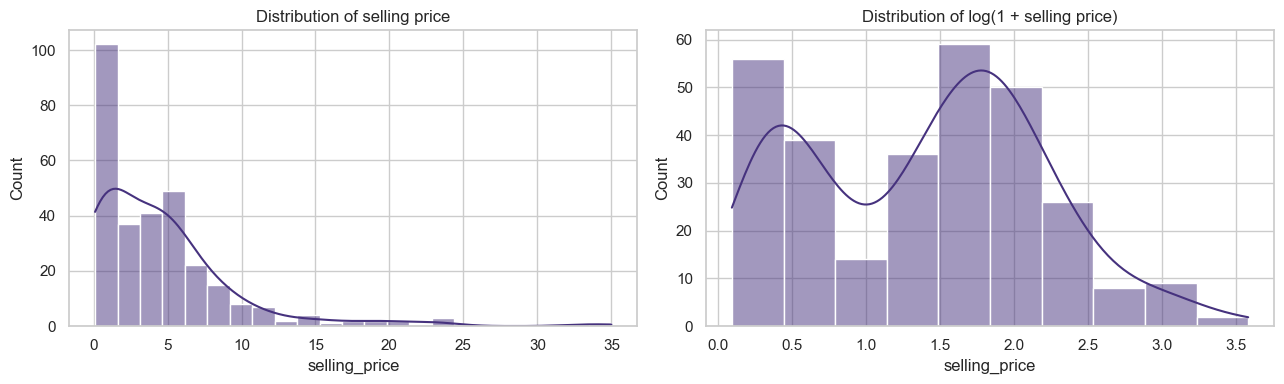

Skewness of selling_price: 2.54


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["selling_price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of selling price")
sns.histplot(np.log1p(df["selling_price"]), kde=True, ax=axes[1])
axes[1].set_title("Distribution of log(1 + selling price)")
plt.tight_layout(); plt.show()
print("Skewness of selling_price:", round(df["selling_price"].skew(), 2))

**Observation:** _(write what you see: is the price right-skewed? are there a few very expensive cars?)_

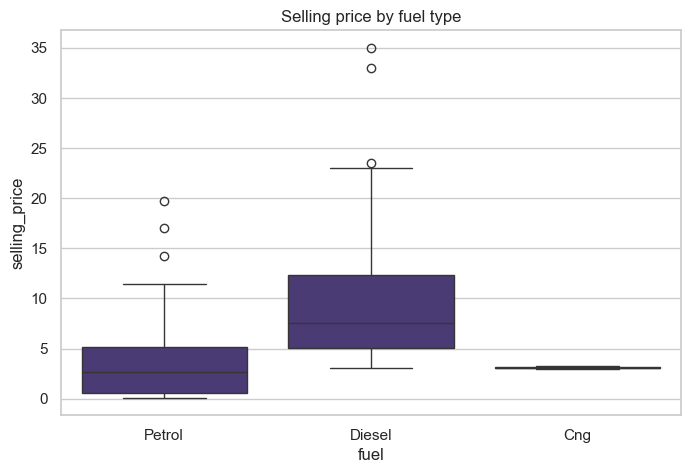

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling price by fuel type"); plt.show()

**Observation:** _(which fuel type has the highest median price? why might that be?)_

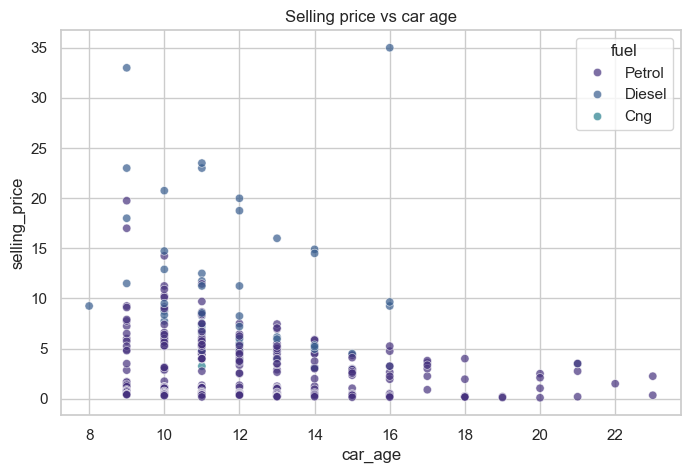

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="selling_price", hue="fuel", alpha=0.7)
plt.title("Selling price vs car age"); plt.show()

**Observation:** _(price should fall as age rises - describe the trend and any outliers)_

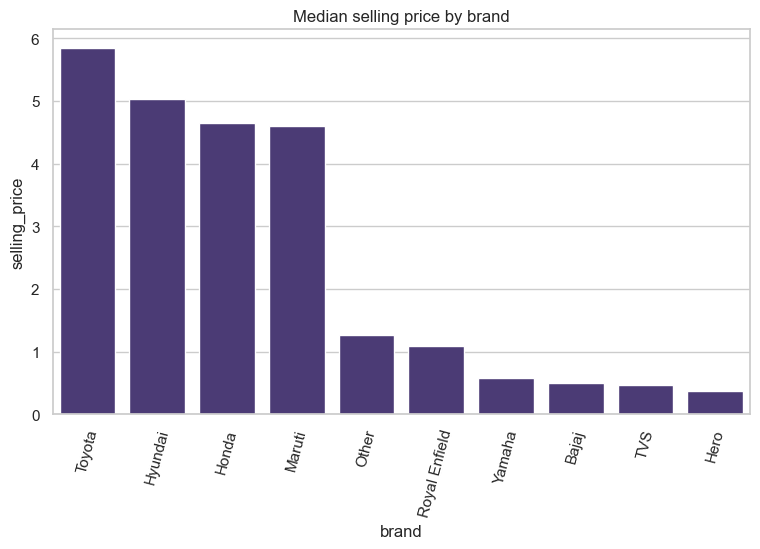

In [29]:
plt.figure(figsize=(9, 5))
order = df.groupby("brand")["selling_price"].median().sort_values(ascending=False).index
sns.barplot(data=df, x="brand", y="selling_price", order=order, estimator=np.median, errorbar=None)
plt.xticks(rotation=75); plt.title("Median selling price by brand"); plt.show()

## 5. Encoding categorical variables

In [30]:
# Drop identifier-like columns, then One-Hot Encode the categoricals
model_df = df.drop(columns=["name", "year"])
cat_features = model_df.select_dtypes(include="object").columns.tolist()
print("Categorical columns being encoded:", cat_features)

model_df = pd.get_dummies(model_df, columns=cat_features, drop_first=True, dtype=int)
print("Shape after encoding:", model_df.shape)
model_df.head()

Categorical columns being encoded: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
Shape after encoding: (299, 19)


,selling_price,present_price,km_driven,car_age,fuel_Diesel,fuel_Petrol,seller_type_Individual,transmission_Manual,owner_1,owner_3,brand_Hero,brand_Honda,brand_Hyundai,brand_Maruti,brand_Other,brand_Royal Enfield,brand_TVS,brand_Toyota,brand_Yamaha
0,3.35,5.59,27000,12,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0
1,4.75,9.54,43000,13,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2,7.25,9.85,6900,9,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0
3,2.85,4.15,5200,15,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0
4,4.60,6.87,42450,12,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0


## 6. Feature correlation heatmap

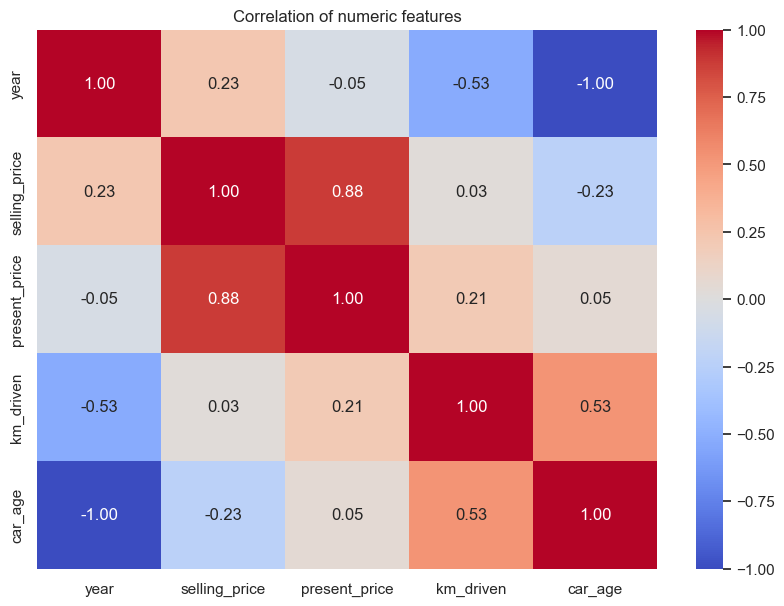

Correlation of all encoded features with selling_price (top 10):
present_price             0.876378
seller_type_Individual    0.553851
fuel_Diesel               0.543541
fuel_Petrol               0.531636
brand_Toyota              0.495393
transmission_Manual       0.348869
car_age                   0.234369
brand_Hero                0.195260
brand_Royal Enfield       0.169984
brand_TVS                 0.137523
Name: selling_price, dtype: float64


In [31]:
plt.figure(figsize=(10, 7))
num_corr = df.select_dtypes(include="number").corr()
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric features"); plt.show()

print("Correlation of all encoded features with selling_price (top 10):")
print(model_df.corr()["selling_price"].drop("selling_price").abs().sort_values(ascending=False).head(10))

**Observation:** _(which numeric features correlate most with price? Note that `present_price`, if your file has it, will be very strong.)_

## 7. Train / test split

In [32]:
X = model_df.drop(columns="selling_price")
y = model_df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (239, 18) | Test: (60, 18)


## 8. Train models

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE),
}

results, preds = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds[name] = p
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, p),
        "RMSE": np.sqrt(mean_squared_error(y_test, p)),
        "R2": r2_score(y_test, p),
        "Train R2": r2_score(y_train, model.predict(X_train)),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,MAE,RMSE,R2,Train R2
Model,,,,
Linear Regression,1.476,2.475,0.762,0.907
Random Forest,1.444,3.523,0.519,0.984
Gradient Boosting,1.158,2.615,0.735,0.998


## 9. Evaluate models

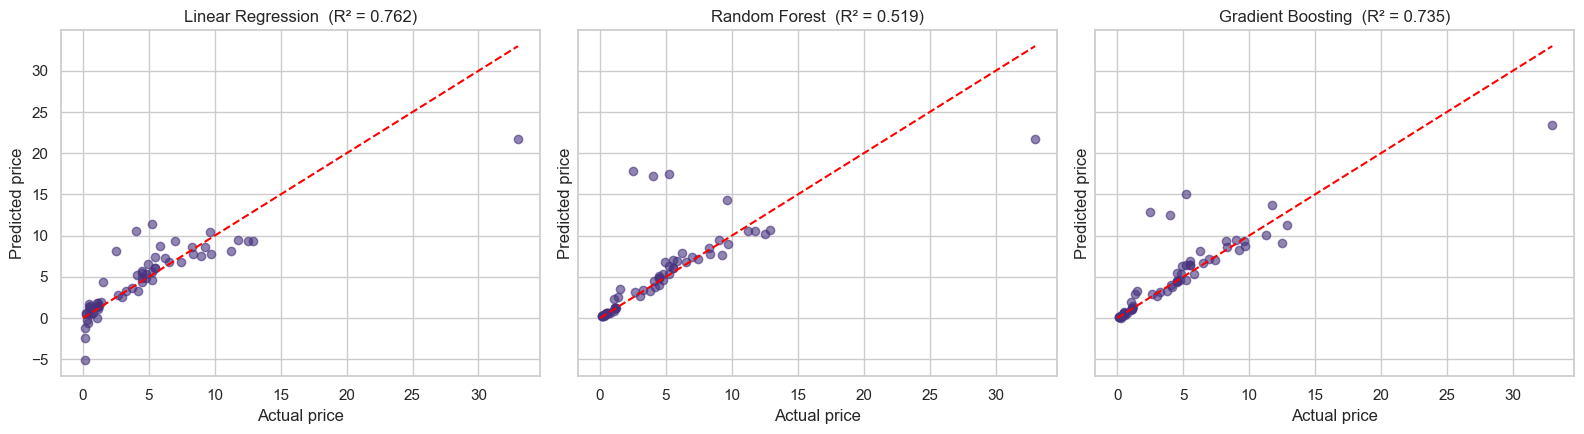

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
lim = [0, max(y_test.max(), max(p.max() for p in preds.values()))]
for ax, (name, p) in zip(axes, preds.items()):
    ax.scatter(y_test, p, alpha=0.6)
    ax.plot(lim, lim, "r--")
    ax.set_title(f"{name}  (R² = {r2_score(y_test, p):.3f})")
    ax.set_xlabel("Actual price"); ax.set_ylabel("Predicted price")
plt.tight_layout(); plt.show()

In [35]:
best_name = results_df["R2"].idxmax()
best_model = models[best_name]
print(f"Best model by R²: {best_name}")
print(results_df.loc[best_name])

Best model by R²: Linear Regression
MAE         1.476
RMSE        2.475
R2          0.762
Train R2    0.907
Name: Linear Regression, dtype: float64


## 10. Feature importance (best model)

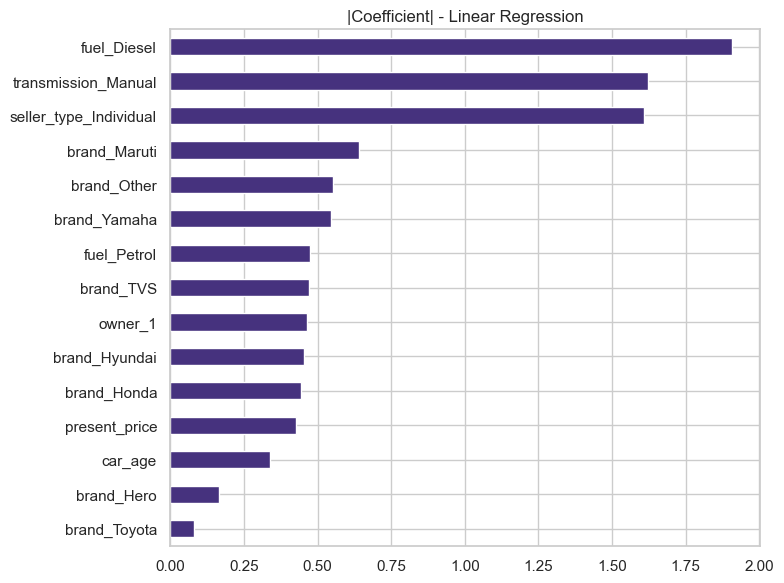

In [36]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
    title = f"Feature importance - {best_name}"
else:  # Linear Regression: use absolute coefficients
    imp = pd.Series(np.abs(best_model.coef_), index=X.columns)
    title = f"|Coefficient| - {best_name}"

top = imp.sort_values(ascending=False).head(15)[::-1]
plt.figure(figsize=(8, 6))
top.plot(kind="barh")
plt.title(title); plt.tight_layout(); plt.show()

## 11. Conclusion
_Fill in with your own numbers after running:_

- **Best model:** _(name)_ with R² = _(x)_, MAE = _(x)_, RMSE = _(x)_ on the test set.
- **Why it won:** _(e.g. tree ensembles capture non-linear depreciation and interactions that Linear Regression cannot)_
- **Key drivers of price:** _(top 3 features from the importance chart)_
- **Limitations:** small dataset, no cross-validation or hyperparameter tuning, price is right-skewed.
- **Next steps:** log-transform the target, k-fold cross-validation, GridSearchCV, try XGBoost.